In [1]:
import pandas as pd

import pypsa

In [5]:
YEAR = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{YEAR}.csv"
costs = pd.read_csv(url, index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs = costs.value.unstack().fillna({"discount rate": 0.07, "lifetime": 20, "FOM": 0})
# costs.head()

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

parameter,Bottom storage temperature,C in fuel,C stored,CO2 intensity,CO2 stored,FOM,Motor size,Top storage temperature,VOM,ammonia-input,...,oil-input,ore-input,p_nom_ratio,pelletizing cost,scrap-input,slag-input,standing losses,temperature difference,wood-input,yield-biochar
technology,,,,,,,,,,,,,,,,,,,,,
Alkaline electrolyzer large size,NaN,NaN,NaN,NaN,NaN,2.8000,NaN,NaN,0.3033,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alkaline electrolyzer medium size,NaN,NaN,NaN,NaN,NaN,2.3000,NaN,NaN,0.3033,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alkaline electrolyzer small size,NaN,NaN,NaN,NaN,NaN,2.3000,NaN,NaN,0.2455,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ammonia cracker,NaN,NaN,NaN,NaN,NaN,4.3000,NaN,NaN,NaN,1.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEV Bus city,NaN,NaN,NaN,NaN,NaN,0.0003,346.5517,NaN,0.1197,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
from pypsa.costs import annuity

a = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

costs["capital_cost"] = (a + costs["FOM"] / 100) * costs["investment"]

In [10]:
RESOLUTION = 3  # hours
url = "https://tubcloud.tu-berlin.de/s/9toBssWEdaLgHzq/download/time-series.csv"
ts = pd.read_csv(url, index_col=0, parse_dates=True)[::RESOLUTION]

ts.head()

,load_mw,pv_pu,wind_pu
timestamp,,,
2019-01-01 00:00:00,5719.26,0.000,0.1846
2019-01-01 03:00:00,5474.74,0.000,0.3146
2019-01-01 06:00:00,5413.39,0.000,0.4957
2019-01-01 09:00:00,5891.23,0.059,0.6824
2019-01-01 12:00:00,6662.42,0.063,0.7519


In [15]:
n = pypsa.Network()
n.add("Bus", "electricity", carrier="electricity")
n.set_snapshots(ts.index)

n.snapshot_weightings.loc[:, :] = RESOLUTION

carriers = [
    "wind",
    "solar",
    "hydrogen storage",
    "battery storage",
    "load shedding",
    "electrolysis",
    "turbine",
    "electricity",
    "hydrogen",
]
colors = [
    "dodgerblue",
    "gold",
    "black",
    "yellowgreen",
    "darkorange",
    "magenta",
    "red",
    "grey",
    "grey",
]
n.add("Carrier", carriers, color=colors)

n.add(
    "Load",
    "demand",
    bus="electricity",
    p_set=ts.load_mw,
)

n.add(
    "Generator",
    "load shedding",
    bus="electricity",
    carrier="load shedding",
    marginal_cost=2000,
    p_nom=ts.load_mw.max(),
)

n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_max_pu=ts.pv_pu,
    capital_cost=costs.at["solar", "capital_cost"],
    marginal_cost=costs.at["solar", "marginal_cost"],
    p_nom_extendable=True,
)

n.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=3,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + 3 * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

n.add("Bus", "hydrogen", carrier="hydrogen")

n.add(
    "Link",
    "electrolysis",
    bus0="electricity",
    bus1="hydrogen",
    carrier="electrolysis",
    p_nom_extendable=True,
    efficiency=costs.at["electrolysis", "efficiency"],
    capital_cost=costs.at["electrolysis", "capital_cost"],
)

n.add(
    "Link",
    "turbine",
    bus0="hydrogen",
    bus1="electricity",
    carrier="turbine",
    p_nom_extendable=True,
    efficiency=costs.at["OCGT", "efficiency"],
    capital_cost=costs.at["OCGT", "capital_cost"] / costs.at["OCGT", "efficiency"],
)

n.add(
    "Store",
    "hydrogen storage",
    bus="hydrogen",
    carrier="hydrogen storage",
    capital_cost=costs.at["hydrogen storage underground", "capital_cost"],
    e_nom_extendable=True,
    e_cyclic=True,
)

n.optimize()

/tmp/ipykernel_839188/2009604028.py:106: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 252.10it/s]
INFO:linopy.io: Writing time: 0.2s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-2x9hvhol has 58405 rows; 26285 cols; 112463 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 3e+00]
  Cost    [2e+02, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+03, 1e+04]
Presolving model
30698 rows, 24863 cols, 83334 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
27778 rows, 21943 cols, 77494 nonzeros  0s
Presolve reductions: rows 27778(-30627); columns 21943(-4342); nonzeros 77494(-34969) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 2920(3.04314e+07) 0.1s
      15605     1.6011601126e+10 Pr: 20598(4.4888e+10); Du: 0(1.76922e-13) 5.3s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26285 primals, 58405 duals
Objective: 1.79e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


      17330     1.7928362934e+10 Pr: 0(0); Du: 0(3.45881e-11) 6.3s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-2x9hvhol
Model status        : Optimal
Simplex   iterations: 17330
Objective value     :  1.7928362934e+10
P-D objective error :  5.3193608356e-16
HiGHS run time      :          6.30


('ok', 'optimal')

In [16]:
tsc = (
    pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1).sum(axis=1).div(1e9)
)
tsc

component    carrier         
Generator    solar               7.145184
Link         electrolysis        1.391874
             turbine             1.904880
StorageUnit  battery storage     4.045755
Store        hydrogen storage    3.422110
Generator    load shedding       0.018560
dtype: float64

In [19]:
tsc.sum()

np.float64(17.928362934003317)

In [20]:
n.statistics.optimal_capacity().div(1e3)

component    carrier         
Generator    load shedding          10.901160
             solar                 110.674848
Link         electrolysis            5.865983
             turbine                12.965740
StorageUnit  battery storage        50.536100
Store        hydrogen storage    18260.702940
dtype: float64

In [21]:
n.statistics.energy_balance(bus_carrier="electricity").sort_values().div(1e6)

component    carrier          bus_carrier
Load         -                electricity   -66.266089
Link         electrolysis     electricity   -30.435916
StorageUnit  battery storage  electricity    -3.671250
Generator    load shedding    electricity     0.009280
Link         turbine          electricity     7.758024
Generator    solar            electricity    92.605951
dtype: float64

(<Figure size 758.25x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance []'>,
 <seaborn.axisgrid.FacetGrid at 0x7c3a08151fd0>)

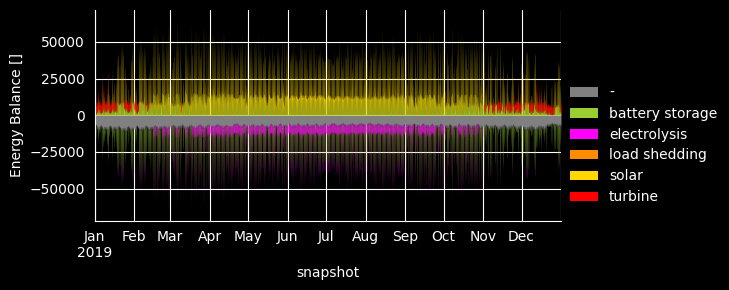

In [22]:
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="electricity")

<Axes: xlabel='snapshot'>

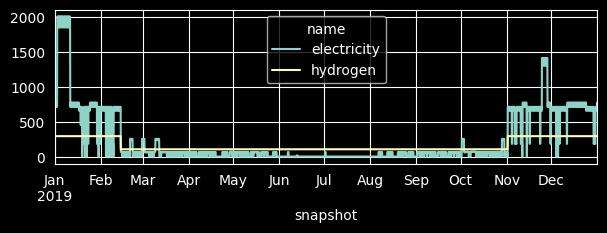

In [23]:
n.buses_t.marginal_price.plot(figsize=(7, 2))